# Distributions, Contour plots and Everything else

In [2]:
import numpy as np
np.random.seed(1337)

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
plt.style.use('ggplot')

In [39]:
num_bins = 20  # number of bins in each dimension  Try: 5, 20, 50, 500 
num_samples = 10000000

data = 100 + 10 * np.random.randn(num_samples, 2)  # generate 100000 2-d random data points
joint_probs, edges = np.histogramdd(data, bins=num_bins)

edges = np.array(edges)[:,1:]

In [40]:
print(edges)

[[ 51.02943299  56.43613257  61.84283215  67.24953174  72.65623132
   78.0629309   83.46963049  88.87633007  94.28302965  99.68972924
  105.09642882 110.5031284  115.90982799 121.31652757 126.72322715
  132.12992674 137.53662632 142.9433259  148.35002549 153.75672507]
 [ 54.33114549  59.45569357  64.58024164  69.70478972  74.82933779
   79.95388586  85.07843394  90.20298201  95.32753009 100.45207816
  105.57662624 110.70117431 115.82572239 120.95027046 126.07481853
  131.19936661 136.32391468 141.44846276 146.57301083 151.69755891]]


In [41]:
joint_probs

array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 2.00000e+00,
        0.00000e+00, 2.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 6.00000e+00, 6.00000e+00, 9.00000e+00, 1.50000e+01,
        1.90000e+01, 6.00000e+00, 5.00000e+00, 2.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.80000e+01, 2.40000e+01, 6.30000e+01, 9.60000e+01, 1.20000e+02,
        1.08000e+02, 1.02000e+02, 5.50000e+01, 2.50000e+01, 1.10000e+01,
        2.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 4.00000e+00, 1.70000e+01,
        7.20000e+01, 2.13000e+02, 4.74000e+02, 6

In [42]:
joint_probs.shape

(20, 20)

In [43]:
cut_point = 2

X_vals = np.array(joint_probs[cut_point])
X_vals /= X_vals.sum()

# Brain twister: Why do we need the cast to np array here?
# leads to a huge bug in analysis if you don't. Can you figure out why?
# Goes back to first semester

Y_vals = np.array( [row[cut_point] for row in joint_probs] )
Y_vals /= Y_vals.sum()

print("Cut X and Y on: ", cut_point)

Cut X and Y on:  2


In [44]:
print(edges[0])
print(X_vals)
print(Y_vals)

[ 51.02943299  56.43613257  61.84283215  67.24953174  72.65623132
  78.0629309   83.46963049  88.87633007  94.28302965  99.68972924
 105.09642882 110.5031284  115.90982799 121.31652757 126.72322715
 132.12992674 137.53662632 142.9433259  148.35002549 153.75672507]
[0.         0.         0.         0.         0.00159744 0.02875399
 0.03833866 0.10063898 0.15335463 0.19169329 0.17252396 0.1629393
 0.08785942 0.0399361  0.01757188 0.00319489 0.         0.00159744
 0.         0.        ]
[0.         0.         0.         0.         0.00282805 0.01300905
 0.03223982 0.0888009  0.1510181  0.20531674 0.20927602 0.15723982
 0.09049774 0.03393665 0.01131222 0.00339367 0.00056561 0.00056561
 0.         0.        ]


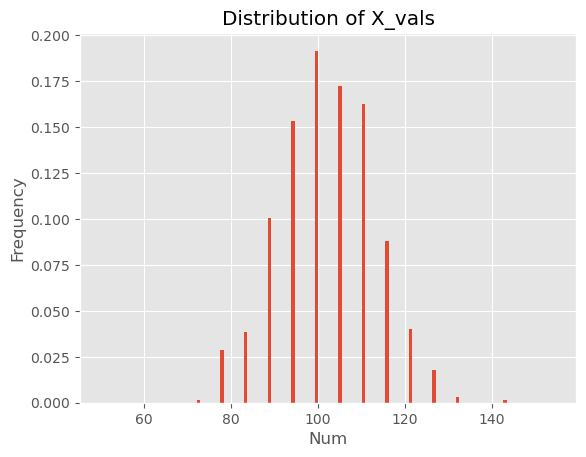

In [45]:
plt.bar(edges[0], X_vals)
plt.ylabel("Frequency")
plt.xlabel("Num")
plt.title("Distribution of X_vals")
plt.show()

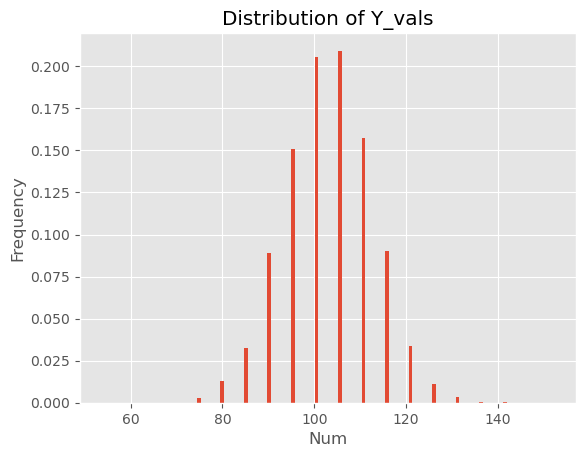

In [46]:
plt.bar(edges[1], Y_vals)
plt.ylabel("Frequency")
plt.xlabel("Num")
plt.title("Distribution of Y_vals")
plt.show()

In [47]:
X = edges[0]
Y = edges[1]
X, Y = np.meshgrid(X, Y)
Z = joint_probs / joint_probs.sum()

Text(0.5, 0, 'z')

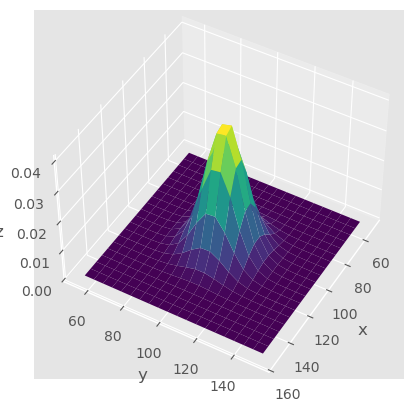

In [48]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')

ax.view_init(45, 30)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

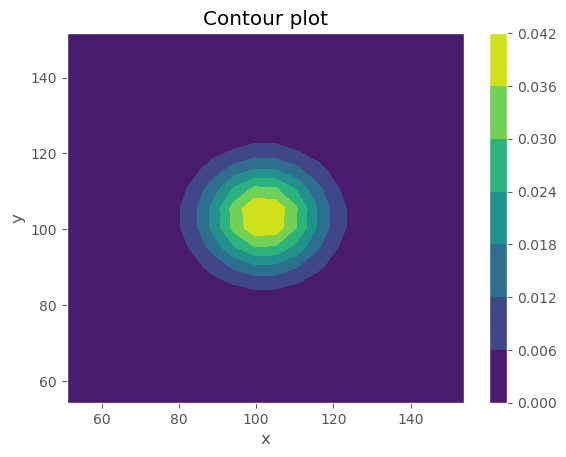

In [49]:
fig, ax = plt.subplots(1,1)
cp = ax.contourf(X, Y, Z)
fig.colorbar(cp)     # add a colorbar to a plot
ax.set_title("Contour plot")
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

# Dependence in joints

In [51]:
import numpy as np

num_bins = 50
num_samples = 10000

# Don't have to understand how these values are being generated
mean = [0, 0]
cov = [[1, 0.8],
       [0.8, 1.0]]        # diagonal covariance

data = 100 + 10 * np.random.multivariate_normal(mean, cov, num_samples)
joint_probs, edges = np.histogramdd(data, bins=num_bins)

edges = np.array(edges)[:, 1:]
print(joint_probs)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]


In [52]:
cut_point = 14      # try 9, 2 and 14

X_vals = np.array(joint_probs[cut_point])
X_vals /= X_vals.sum()

Y_vals = np.array( [row[cut_point] for row in joint_probs] )
Y_vals /= Y_vals.sum()

print('Cut X and Y on: ', cut_point)

Cut X and Y on:  14


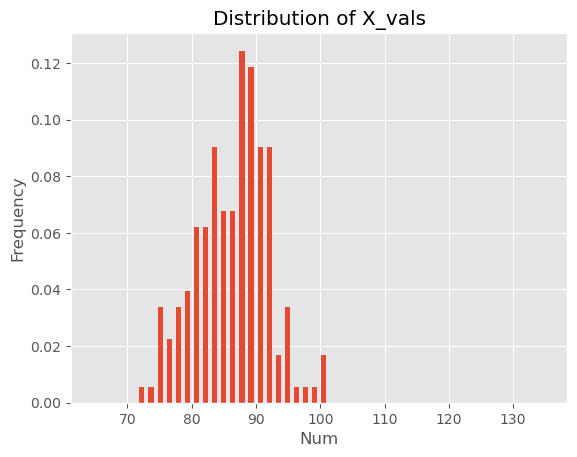

In [53]:
plt.bar(edges[0], X_vals)
plt.ylabel('Frequency')
plt.xlabel('Num')
plt.title('Distribution of X_vals')
plt.show()

In [54]:
# plt.bar(edges[1], Y_vals)   #       Let's not do this for Y right now 
# plt.ylabel('Frequency')
# plt.xlabel('Num');
# plt.title("Distribution of Y_vals")
# plt.show()

In [55]:
X = edges[0]
Y = edges[1]

X, Y = np.meshgrid(X, Y)
Z = joint_probs / joint_probs.sum()

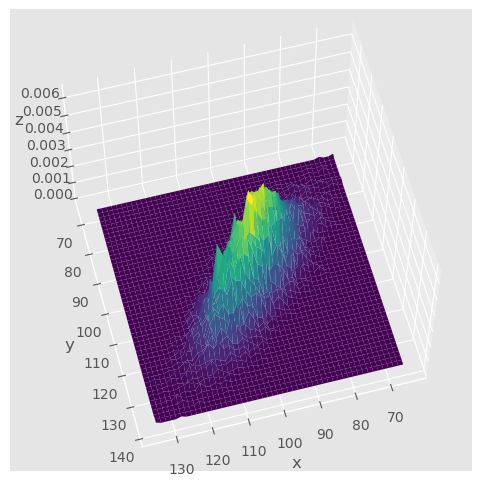

In [56]:
fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection='3d')

ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap='viridis')

ax.view_init(60, 75)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z');

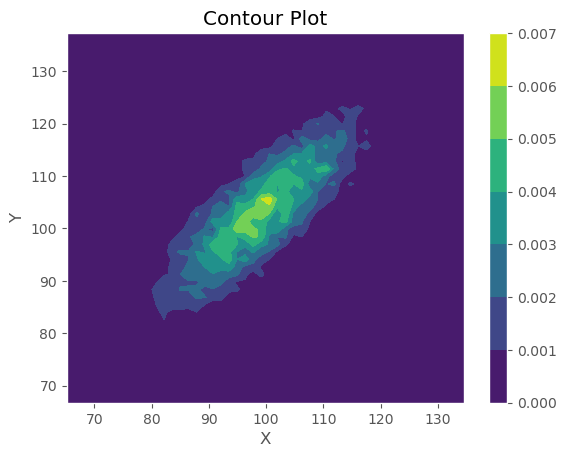

In [57]:
fig,ax = plt.subplots(1,1)
cp = ax.contourf(X, Y, Z)
fig.colorbar(cp) # Add a colorbar to a plot
ax.set_title('Contour Plot')
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()